# Hands On - CoLoMoTo notebook
- WTAC - Computational Systems Biology for Digital Medicine
- Wellcome Genome Campus, UK
- 7–12 December 2025

Loading a model, computing stable states, checking for phenotype markers, and reachability verification

## Loading & Visualizing the regulatory graph (LRG)

In [1]:
import ginsim

This notebook has been executed using the docker image `colomoto/colomoto-docker:2025-12-01`

Load the Th model

In [2]:
# We'll use the old/simpler/faster one: http://ginsim.org/sites/default/files/Th_17.zginml
# load() accepts either a local or a remote file
lrg = ginsim.load("http://ginsim.org/sites/default/files/Th_17.zginml")

/notebook/Th_17.zginml

Display the regulatory graph, as defined in GINsim.

In [3]:
# node convention: oval -> Boolean, rectangle -> multivalued
ginsim.show(lrg)

---
## Computing stable states

### using bioLQM

In [4]:
import biolqm

bioLQM documentation: http://colomoto.org/biolqm/

In [5]:
### Convert the ginsim model to biolqm
lqm = ginsim.to_biolqm(lrg)

In [6]:
### Compute the stable states
fps_lqm = biolqm.fixpoints(lqm)

In [7]:
from colomoto_jupyter import tabulate
### Display the list of stable states
tabulate(fps_lqm)

,IFNg,IFNgR,STAT1,Tbet,SOCS1,IFNb,IFNbR,IL18,IL18R,IRAK,IL12,IL12R,STAT4,IL4,IL4R,STAT6,GATA3
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1
2,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
3,2,1,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
### Show an overlay of state values (of a given stable state) on the LRG
ginsim.show(lrg, fps_lqm[1])

### using Pint

In [9]:
import pypint

In [10]:
### Convert the biolqm model to a pint model
ppm = biolqm.to_pint(lqm)

In [43]:
# ALTERNATIVE: load the model directly with pypint
# The load function supports GINsim or Cell Collective model URLs
#ppm = pypint.load("http://ginsim.org/sites/default/files/Th_17.zginml")

/notebook/Th_17.zginml

In [44]:
### Now compute the stable states using pint
ppm_fps = pypint.fixpoints(ppm)

In [45]:
### Display the list of stable states
tabulate(ppm_fps)

,IFNg,IFNgR,STAT1,Tbet,SOCS1,IFNb,IFNbR,IL18,IL18R,IRAK,IL12,IL12R,STAT4,IL4,IL4R,STAT6,GATA3
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1
2,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
3,2,1,1,2,1,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
### Using GINsim & the new stable state list, show an overlay of state values (of a given stable state) on the LRG
ginsim.show(lrg, ppm_fps[2])

---
## Using the Th 2010 model (with thousands of stable states)

Pint is faster to compute stable states.

So, for the Th 2010 model we'll only use Pint. Still, it's a reduced version. 

Let's now try to load & view the Th model from 2010 (http://ginsim.org/node/79).

In [14]:
# http://ginsim.org/sites/default/files/Th_differentiation_reduced_model.zginml
lrg_Th2010 = ginsim.load("http://ginsim.org/sites/default/files/Th_differentiation_reduced_model.zginml")
ginsim.show(lrg_Th2010)

/notebook/Th_differentiation_reduced_model.zginml

Convert the GINsim model to bioLQM model.

In [15]:
lqm_Th2010 = ginsim.to_biolqm(lrg_Th2010)

Convert the bioLQM model to a Pint model.

In [16]:
pint_Th2010 = biolqm.to_pint(lqm_Th2010)

Compute & view the stable states using Pint.

In [17]:
fps_pint_Th2010 = pypint.fixpoints(pint_Th2010)
tabulate(fps_pint_Th2010)

,APC,IFNB_e,IFNG_e,IL2_e,IL4_e,IL6_e,IL10_e,IL12_e,IL15_e,IL21_e,IL23_e,IL27_e,TGFB_e,IL2R,IL2RA,IFNG,IL2,IL4,IL10,IL21,IL23,TGFB,TBET,GATA3,FOXP3,NFAT,STAT1,STAT3,STAT4,STAT5,STAT6,proliferation,RORGT,IL17
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65943,1,1,1,1,1,1,1,1,1,1,1,1,0,2,1,0,0,0,1,1,1,1,1,0,1,1,1,1,0,2,1,1,1,0
66938,1,1,1,1,1,1,1,1,1,1,1,1,1,2,1,0,0,0,1,1,1,0,0,1,0,1,1,1,0,2,1,1,1,0
66934,1,1,1,1,1,1,1,1,1,1,1,1,1,2,1,0,0,0,1,1,1,0,1,0,0,1,1,1,0,2,1,1,1,0
66939,1,1,1,1,1,1,1,1,1,1,1,1,1,2,1,0,0,0,1,1,1,1,0,1,1,1,1,1,0,2,1,1,1,0


Show a Pint stable state on the LRG.

In [18]:
ginsim.show(lrg_Th2010, fps_pint_Th2010[2000])

### Verifying the presence of phenotypes markers
First, define the list of phenotypes to observe

https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1000912

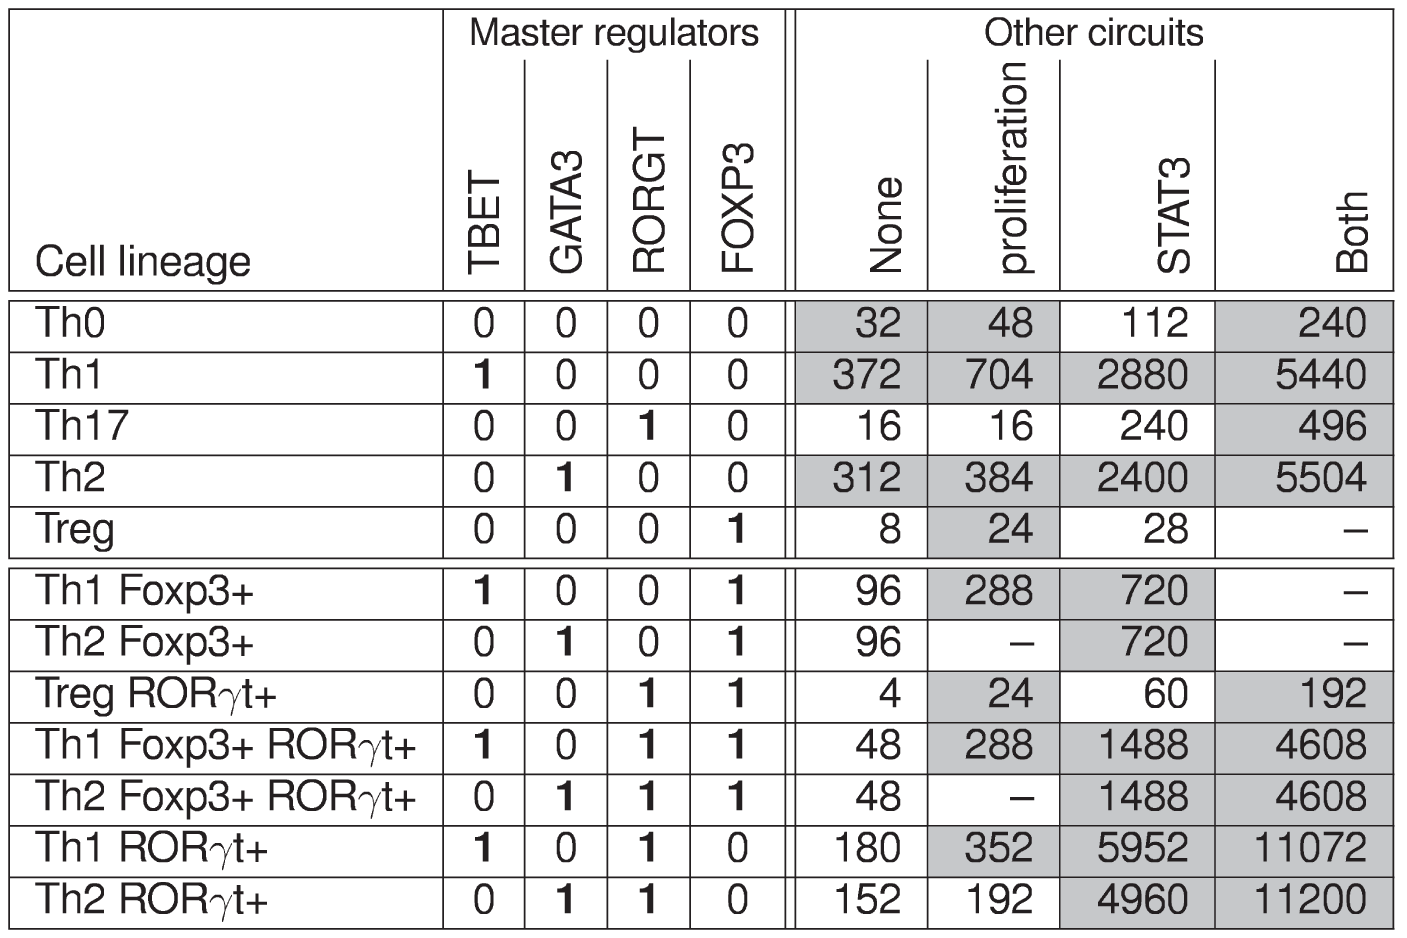

In [19]:
phenotypes = {
    'Th0': {'TBET':0, 'GATA3':0, 'RORGT':0, 'FOXP3': 0},
    'Th1': {'TBET':1, 'GATA3':0, 'RORGT':0, 'FOXP3': 0},
    'Th17': {'TBET':0, 'GATA3':0, 'RORGT':1, 'FOXP3': 0},
    'Th2': {'TBET':0, 'GATA3':1, 'RORGT':0, 'FOXP3': 0},
    'Threg': {'TBET':0, 'GATA3':0, 'RORGT':0, 'FOXP3': 1},
    'Th1_Foxp3': {'TBET':1, 'GATA3':0, 'RORGT':0, 'FOXP3': 1},
    'Th2_Foxp3': {'TBET':0, 'GATA3':1, 'RORGT':0, 'FOXP3': 1},
    'Treg_RORGT': {'TBET':0, 'GATA3':0, 'RORGT':1, 'FOXP3': 1},
    'Th1_Foxp3_RORGT': {'TBET':1, 'GATA3':0, 'RORGT':1, 'FOXP3': 1},
    'Th2_Foxp3_RORGT': {'TBET':0, 'GATA3':1, 'RORGT':1, 'FOXP3': 1},
    'Th1_RORGT': {'TBET':1, 'GATA3':0, 'RORGT':1, 'FOXP3': 0},
    'Th2_RORGT': {'TBET':0, 'GATA3':1, 'RORGT':1, 'FOXP3': 0},
}

Iterate through the set of stable states

In [20]:
for pheno in phenotypes:
    print(pheno, len([fp for fp in fps_pint_Th2010 \
        if all(fp[g]==phenotypes[pheno][g] for g in phenotypes[pheno])]))    

Th0 432
Th1 9396
Th17 768
Th2 8600
Threg 60
Th1_Foxp3 1104
Th2_Foxp3 816
Treg_RORGT 280
Th1_Foxp3_RORGT 6432
Th2_Foxp3_RORGT 6144
Th1_RORGT 17556
Th2_RORGT 16504


---
## Reachability verification
Defining the list of environmental conditions

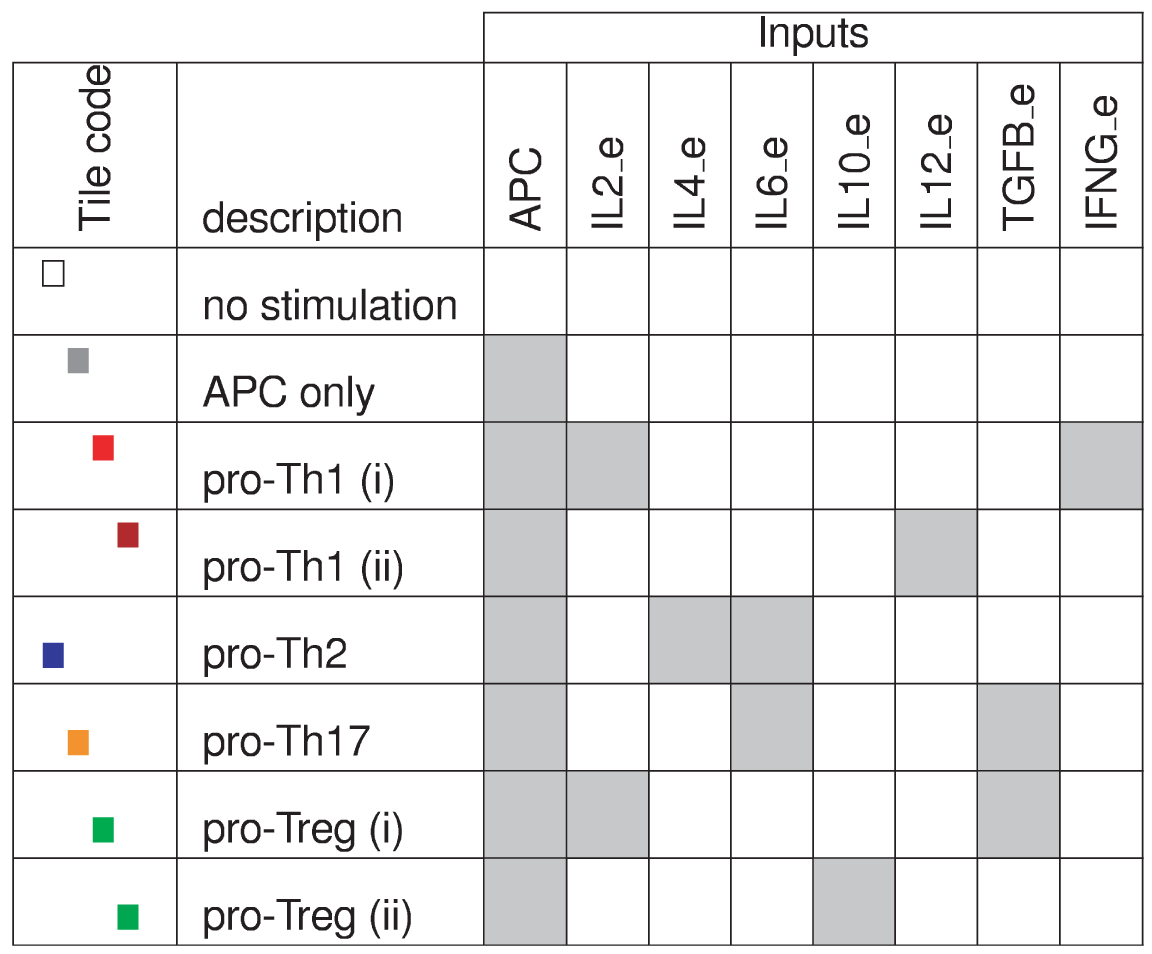

In [21]:
inputs = {
    'nostml':   {'APC':0, 'IL2_e':0, 'IL4_e':0, 'IL6_e':0, 'IL10_e':0, 'IL12_e':0, 'TGFB_e':0, 'IFNG_e':0},
    'APC':      {'APC':1, 'IL2_e':0, 'IL4_e':0, 'IL6_e':0, 'IL10_e':0, 'IL12_e':0, 'TGFB_e':0, 'IFNG_e':0},
    'proTh1_1': {'APC':1, 'IL2_e':1, 'IL4_e':0, 'IL6_e':0, 'IL10_e':0, 'IL12_e':0, 'TGFB_e':0, 'IFNG_e':1},
    'proTh1_2': {'APC':1, 'IL2_e':0, 'IL4_e':0, 'IL6_e':0, 'IL10_e':0, 'IL12_e':1, 'TGFB_e':0, 'IFNG_e':0},
    'proTh2':   {'APC':1, 'IL2_e':0, 'IL4_e':1, 'IL6_e':1, 'IL10_e':0, 'IL12_e':0, 'TGFB_e':0, 'IFNG_e':0},
    'proTh17':  {'APC':1, 'IL2_e':0, 'IL4_e':0, 'IL6_e':1, 'IL10_e':0, 'IL12_e':0, 'TGFB_e':1, 'IFNG_e':0},
    'proTreg_1':{'APC':1, 'IL2_e':1, 'IL4_e':0, 'IL6_e':0, 'IL10_e':0, 'IL12_e':0, 'TGFB_e':1, 'IFNG_e':0},
    'proTreg_2':{'APC':1, 'IL2_e':0, 'IL4_e':0, 'IL6_e':0, 'IL10_e':1, 'IL12_e':0, 'TGFB_e':0, 'IFNG_e':0},
}

### Using BoolSim
Symbolically compute all reachable states from Th0, using a proTh2 environment

In [22]:
import boolsim

In [23]:
init = { **phenotypes['Th0'], **inputs['proTh2']}
Th0_proTh2 = boolsim.reachable(lrg, init)

In [24]:
# Is Th2 in the cone of Th0 reachable states ?
Th0_proTh2_Th2 = [s for s in Th0_proTh2 if s['GATA3']==1]
tabulate(Th0_proTh2_Th2)

,GATA3,IFNb,IFNbR,IFNg_b1,IFNg_b2,IFNgR_b1,IFNgR_b2,IL12,IL12R,IL18,IL18R,IL4,IL4R,IRAK,SOCS1,STAT1_b1,STAT1_b2,STAT4,STAT6,Tbet_b1,Tbet_b2
0,1,*,*,0,0,*,*,*,*,*,*,0,0,*,0,0,1,0,0,0,*
1,1,*,*,0,0,*,*,*,*,*,*,1,*,*,0,0,1,0,0,0,*
3,1,*,*,0,0,*,*,*,*,*,*,*,0,*,1,0,1,0,0,0,*
2,1,*,*,0,0,*,*,*,*,*,*,*,*,*,0,0,1,0,1,0,*
4,1,*,*,0,0,*,*,*,*,*,*,*,*,*,1,0,1,0,1,0,*
5,1,*,*,0,1,0,*,*,*,*,*,0,0,*,0,0,1,0,0,0,*
6,1,*,*,0,1,0,*,*,*,*,*,1,*,*,0,0,1,0,0,0,*
8,1,*,*,0,1,0,*,*,*,*,*,*,0,*,1,0,1,0,0,0,*
7,1,*,*,0,1,0,*,*,*,*,*,*,*,*,0,0,1,0,1,0,*
9,1,*,*,0,1,0,*,*,*,*,*,*,*,*,1,0,1,0,1,0,*


### Using NuSMV model checker

We will CTL to express properties on trajectories related to the reachability of lytic and lysogenic attractors.

The Python module `colomoto.temporal_logics` provides a programmatic way to specify CTL and LTL properties.

In [25]:
from colomoto.temporal_logics import *

States are specified using the `S` operator. The following property characterize the initial state when all the nodes are inactive.

In [26]:
is_Th0_proTh2 = S(
APC=1,
IFNB_e=0,
IFNG_e=0,
IL2_e=0,
IL4_e=1,
IL6_e=0,
IL10_e=0,
IL12_e=0,
IL15_e=0,
IL21_e=0,
IL23_e=0,
IL27_e=0,
TGFB_e=0,
IL2R=0,
IL2RA=0,
IFNG=0,
IL2=0,
IL4=0,
IL10=0,
IL21=0,
IL23=0,
TGFB=0,
TBET=0,
GATA3=0,
FOXP3=0,
NFAT=0,
STAT1=0,
STAT3=0,
STAT4=0,
STAT5=0,
STAT6=0,
proliferation=0,
RORGT=0,
IL17=0)

The Th2 state is characterised by:

In [27]:
print(phenotypes['Th2'])

{'TBET': 0, 'GATA3': 1, 'RORGT': 0, 'FOXP3': 0}


In [28]:
s_Th2 = S(TBET=0, GATA3=1, RORGT=0, FOXP3=0)

NuSMV is a symbolic model checker which checks if the provided model verifies a given set of CTL/LTL properties.

GINsim provides a translation of Boolean and multivalued networks into NuSMV models.

In [29]:
smv = ginsim.to_nusmv(lrg)

Here, `smv` is a Python object representing the NuSMV model. CTL/LTL specification can be added using the method `add_ctl` and `add_ltl`, respectively. For convenience, a label can be given to a property:

In [30]:
specs = {
    "EF_Th2": If(is_Th0_proTh2, EF(s_Th2))
}
# could add more specifications...
smv.add_ctls(specs)

The method `verify` will execute NuSMV and returns the verification result for each property:



In [31]:
smv.verify()

CmdError: Command 'NuSMV -dcx -coi /tmp/tmpgftjpmrd.smv' returned non-zero exit status 1

WARNING: single-value variable 'PC_c1_vars' has been stored as a constant
WARNING: single-value variable 'PC_c2_vars' has been stored as a constant
WARNING: single-value variable 'PC_c3_vars' has been stored as a constant
WARNING: single-value variable 'PC_c4_vars' has been stored as a constant
WARNING: single-value variable 'PC_c5_vars' has been stored as a constant
WARNING: single-value variable 'PC_c6_vars' has been stored as a constant
WARNING: single-value variable 'PC_c7_vars' has been stored as a constant
WARNING: single-value variable 'PC_c8_vars' has been stored as a constant
WARNING: single-value variable 'PC_c9_vars' has been stored as a constant
WARNING: single-value variable 'PC_c10_vars' has been stored as a constant
WARNING: single-value variable 'PC_c11_vars' has been stored as a constant
WARNING: single-value variable 'PC_c12_vars' has been stored as a constant
WARNING: single-value variable 'PC_c13_vars' has been stored as a constant
WARNING: single-value variable 'PC_c14_vars' has been stored as a constant
WARNING: single-value variable 'PC_c15_vars' has been stored as a constant
WARNING: single-value variable 'PC_c16_vars' has been stored as a constant
WARNING: single-value variable 'PC_c17_vars' has been stored as a constant

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'APC'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IFNB_e'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IFNG_e'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL2_e'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL4_e'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL6_e'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL10_e'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL12_e'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL15_e'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL21_e'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL23_e'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL27_e'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'TGFB_e'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL2R'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL2RA'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IFNG'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL2'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL10'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL21'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL23'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'TGFB'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'TBET'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'FOXP3'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'NFAT'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'STAT3'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'STAT5'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'proliferation'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'RORGT'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'IL17'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'TBET'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'RORGT'

TYPE ERROR file /tmp/tmpgftjpmrd.smv: line 419 : undefined identifier 'FOXP3'
ERROR: Property "((((((((((((((((((((((((((((((((((APC = 1 & IFNB_e = 0) & IFNG_e = 0) & IL2_e = 0) & IL4_e = 1) & IL6_e = 0) & IL10_e = 0) & IL12_e = 0) & IL15_e = 0) & IL21_e = 0) & IL23_e = 0) & IL27_e = 0) & TGFB_e = 0) & IL2R = 0) & IL2RA = 0) & IFNG = 0) & IL2 = 0) & IL4 = 0) & IL10 = 0) & IL21 = 0) & IL23 = 0) & TGFB = 0) & TBET = 0) & GATA3 = 0) & FOXP3 = 0) & NFAT = 0) & STAT1 = 0) & STAT3 = 0) & STAT4 = 0) & STAT5 = 0) & STAT6 = 0) & proliferation = 0) & RORGT = 0) & IL17 = 0) -> EF (((TBET = 0 & GATA3 = 1) & RORGT = 0) & FOXP3 = 0)) " is not correct or not well typed.

Aborting batch mode

NuSMV terminated by a signal

Aborting batch mode



We can try a different microenvironment to Th0 and check if the Th2 reachability still holds.

In [32]:
is_Th0_proTreg = S(
APC=1,
IFNB_e=0,
IFNG_e=0,
IL2_e=1,
IL4_e=0,
IL6_e=0,
IL10_e=0,
IL12_e=0,
IL15_e=0,
IL21_e=0,
IL23_e=0,
IL27_e=0,
TGFB_e=1,
IL2R=0,
IL2RA=0,
IFNG=0,
IL2=0,
IL4=0,
IL10=0,
IL21=0,
IL23=0,
TGFB=0,
TBET=0,
GATA3=0,
FOXP3=0,
NFAT=0,
STAT1=0,
STAT3=0,
STAT4=0,
STAT5=0,
STAT6=0,
proliferation=0,
RORGT=0,
IL17=0)

In [33]:
specs = {
    "EF_proTh2_Th2": If(is_Th0_proTh2, EF(s_Th2)),
    "EF_proTreg_Th2": If(is_Th0_proTreg, EF(s_Th2))
}
# could add more specifications...
smv.add_ctls(specs)

In [34]:
smv.verify()

CmdError: Command 'NuSMV -dcx -coi /tmp/tmpxtoa6_od.smv' returned non-zero exit status 1

WARNING: single-value variable 'PC_c1_vars' has been stored as a constant
WARNING: single-value variable 'PC_c2_vars' has been stored as a constant
WARNING: single-value variable 'PC_c3_vars' has been stored as a constant
WARNING: single-value variable 'PC_c4_vars' has been stored as a constant
WARNING: single-value variable 'PC_c5_vars' has been stored as a constant
WARNING: single-value variable 'PC_c6_vars' has been stored as a constant
WARNING: single-value variable 'PC_c7_vars' has been stored as a constant
WARNING: single-value variable 'PC_c8_vars' has been stored as a constant
WARNING: single-value variable 'PC_c9_vars' has been stored as a constant
WARNING: single-value variable 'PC_c10_vars' has been stored as a constant
WARNING: single-value variable 'PC_c11_vars' has been stored as a constant
WARNING: single-value variable 'PC_c12_vars' has been stored as a constant
WARNING: single-value variable 'PC_c13_vars' has been stored as a constant
WARNING: single-value variable 'PC_c14_vars' has been stored as a constant
WARNING: single-value variable 'PC_c15_vars' has been stored as a constant
WARNING: single-value variable 'PC_c16_vars' has been stored as a constant
WARNING: single-value variable 'PC_c17_vars' has been stored as a constant

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'APC'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IFNB_e'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IFNG_e'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL2_e'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL4_e'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL6_e'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL10_e'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL12_e'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL15_e'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL21_e'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL23_e'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL27_e'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'TGFB_e'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL2R'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL2RA'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IFNG'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL2'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL10'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL21'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL23'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'TGFB'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'TBET'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'FOXP3'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'NFAT'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'STAT3'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'STAT5'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'proliferation'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'RORGT'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'IL17'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'TBET'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'RORGT'

TYPE ERROR file /tmp/tmpxtoa6_od.smv: line 419 : undefined identifier 'FOXP3'
ERROR: Property "((((((((((((((((((((((((((((((((((APC = 1 & IFNB_e = 0) & IFNG_e = 0) & IL2_e = 0) & IL4_e = 1) & IL6_e = 0) & IL10_e = 0) & IL12_e = 0) & IL15_e = 0) & IL21_e = 0) & IL23_e = 0) & IL27_e = 0) & TGFB_e = 0) & IL2R = 0) & IL2RA = 0) & IFNG = 0) & IL2 = 0) & IL4 = 0) & IL10 = 0) & IL21 = 0) & IL23 = 0) & TGFB = 0) & TBET = 0) & GATA3 = 0) & FOXP3 = 0) & NFAT = 0) & STAT1 = 0) & STAT3 = 0) & STAT4 = 0) & STAT5 = 0) & STAT6 = 0) & proliferation = 0) & RORGT = 0) & IL17 = 0) -> EF (((TBET = 0 & GATA3 = 1) & RORGT = 0) & FOXP3 = 0)) " is not correct or not well typed.

Aborting batch mode

NuSMV terminated by a signal

Aborting batch mode



### Using Pint

In [35]:
import pypint

In [36]:
# The load function supports GINsim or Cell Collective model URLs
pintm = pypint.load("http://ginsim.org/sites/default/files/Th_differentiation_reduced_model.zginml")

/notebook/Th_differentiation_reduced_model.zginml

18 state(s) have been registered: Th0, Th1, Th2, Th1_a, Th2_a, Treg, Th1_r, Th2_r, Th1_n, Th2_n, Treg_1, Th17_1, Treg_r, Treg_r1, Treg_r2, Th0_a, Th17_n, CircuitNeg_Stat5Foxp3

In [37]:
# Define the Th0 as the initial state
pintm.initial_state = pintm.named_states["Th0"]

Consider the APC=1 environment

In [39]:
pintm.having(APC=1).reachability(phenotypes['Th0'])

True

In [40]:
pintm.having(APC=1).reachability(phenotypes['Th1'])

False

In [41]:
pintm.having(APC=1).reachability(phenotypes['Th2'])

False

Consider the proTh2 cell environment

In [42]:
pintm.having(APC=1,IL4_e=1,IL6_e=1).reachability(phenotypes['Th1'])

True

In [42]:
pintm.having(APC=1,IL4_e=1,IL6_e=1).reachability(phenotypes['Th2'])

True

In [51]:
# Go to the paper and check for the presence/absence of all combinations of phenotypes / microenvironments